# 03: Training
4-stage progressive training。Full 和 Lite 各跑一次。

**設定 `VARIANT` 後直接 Run All。**

| Stage | 啟用元件 | Epochs |
|-------|---------|--------|
| 1 | Spatial only | 40 |
| 2 | + Freq branch | 30 |
| 3 | + Cross attention | 30 |
| 4 | + Adaptive router | 20 |

In [6]:
# ============================================================
# CONFIG — 改這裡就好
# ============================================================
VARIANT    = 'full'                       # 'full' 或 'lite'
DATA_ROOT  = '/workspace/zenodo_tmp'
OUTPUT_DIR = f'./checkpoints_{VARIANT}'

CONFIG = {
    'base_features':    32,
    'batch_size':       2,      # Full model 需要 2，Lite 可以用 4
    'target_size':      (128, 128, 128),
    'epochs_per_stage': [40, 30, 30, 20],
    'num_workers':      4,
    'lr':               1e-4,
    'random_seed':      42,
    'weight_decay':     1e-5,
    'use_amp':          True,   # 混合精度，省約 40% VRAM
}

# 從哪個 stage 開始（0-indexed）
# Stage 1 已跑完 → START_STAGE=1，全部重跑 → START_STAGE=0
START_STAGE = 3

N_TRAIN = 91; N_VAL = 19; N_TEST = 20

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'VARIANT={VARIANT}  batch_size={CONFIG["batch_size"]}  AMP={CONFIG["use_amp"]}')
print(f'START_STAGE={START_STAGE+1}  (stages {START_STAGE+1}~4 will run)')

VARIANT=full  batch_size=2  AMP=True
START_STAGE=4  (stages 4~4 will run)


In [7]:
# ============================================================
# Cell 2: Load model definitions
# ============================================================
%run 02_model.ipynb


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip i

✅ Packages ready
Device: cuda
GPU: NVIDIA A40
VRAM: 47.7 GB
✅ MultiScaleWavelet3D, DoubleConv
✅ FrequencyBranchV4 (Full)
✅ FrequencyBranchLite
✅ CrossDomainAttention, AdaptiveRouter
AFS_DSN_V4 Full: 414.57M params
AFS_DSN_Lite: 27.41M params
✅ AFS_DSN_V4, AFS_DSN_Lite
✅ NasalSegDataset
✅ CombinedLoss, dice_coefficient, compute_dice_np
02_model.ipynb ready
  AFS_DSN_V4()   — full (~414M)
  AFS_DSN_Lite() — lite (~80M)
  NasalSegDataset(root)
  CombinedLoss() — CE + Dice


In [8]:
# ============================================================
# Cell 3: Dataset split (固定 seed=42，存 JSON)
# ============================================================
import json
import numpy as np
from torch.utils.data import DataLoader, Subset

np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

full_dataset = NasalSegDataset(DATA_ROOT, target_size=CONFIG['target_size'])
indices = np.arange(len(full_dataset))
np.random.shuffle(indices)

train_idx = indices[:N_TRAIN].tolist()
val_idx   = indices[N_TRAIN:N_TRAIN+N_VAL].tolist()
test_idx  = indices[N_TRAIN+N_VAL:].tolist()

split_path = f'{OUTPUT_DIR}/split_indices.json'
with open(split_path, 'w') as f:
    json.dump({'train':train_idx,'val':val_idx,'test':test_idx,
               'seed':CONFIG['random_seed']}, f, indent=2)
print(f'Split saved: {split_path}')
print(f'  Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(test_idx)}')

train_loader = DataLoader(Subset(full_dataset, train_idx),
                          batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx),
                          batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)

📊 Found 130 samples
Split saved: ./checkpoints_full/split_indices.json
  Train:91 Val:19 Test:20


In [9]:
# ============================================================
# Cell 4: Training helpers — 加入 AMP 混合精度
# ============================================================
from tqdm import tqdm
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=CONFIG['use_amp'])

def train_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss=0; total_dice=0
    pbar=tqdm(loader, desc=f'Epoch {epoch}')
    for images,masks in pbar:
        images,masks=images.to(device),masks.to(device)
        optimizer.zero_grad()
        with autocast(enabled=CONFIG['use_amp']):
            outputs=model(images)
            loss=criterion(outputs['output'],masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        dice=dice_coefficient(outputs['output'],masks)
        total_loss+=loss.item(); total_dice+=dice
        pbar.set_postfix({'loss':f'{loss.item():.4f}','dice':f'{dice:.4f}'})
    return total_loss/len(loader), total_dice/len(loader)

def validate(model, loader, criterion):
    model.eval(); total_loss=0; total_dice=0
    with torch.no_grad():
        for images,masks in tqdm(loader, desc='Validation'):
            images,masks=images.to(device),masks.to(device)
            with autocast(enabled=CONFIG['use_amp']):
                outputs=model(images)
                loss=criterion(outputs['output'],masks)
            total_loss+=loss.item()
            total_dice+=dice_coefficient(outputs['output'],masks)
    return total_loss/len(loader), total_dice/len(loader)

print('✅ train_epoch, validate ready (AMP enabled)')

✅ train_epoch, validate ready (AMP enabled)


/tmp/ipykernel_5481/601546610.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG['use_amp'])


In [10]:
# ============================================================
# Cell 5: 4-stage progressive training
# START_STAGE=1 → 跳過 Stage1，從 Stage2 開始
# ============================================================
import matplotlib.pyplot as plt

MODEL_CLS = AFS_DSN_V4 if VARIANT=='full' else AFS_DSN_Lite
criterion = CombinedLoss(num_classes=2)

stage_cfgs = [
    {'name':'Stage1_Spatial',   'freq':False,'attn':False,'router':False},
    {'name':'Stage2_FreqBranch','freq':True, 'attn':False,'router':False},
    {'name':'Stage3_CrossAttn', 'freq':True, 'attn':True, 'router':False},
    {'name':'Stage4_FullModel', 'freq':True, 'attn':True, 'router':True},
]

history = {}

# Stage1 已跑完 → 載入 checkpoint 作為起點
if START_STAGE > 0:
    ck_path = f'{OUTPUT_DIR}/{stage_cfgs[START_STAGE-1]["name"]}_best.pth'
    model = MODEL_CLS(
        num_classes=2, base_features=CONFIG['base_features'],
        **{k: stage_cfgs[START_STAGE-1][k] for k in ['freq','attn','router']}
        if False else dict(
            use_freq_branch=stage_cfgs[START_STAGE-1]['freq'],
            use_cross_attention=stage_cfgs[START_STAGE-1]['attn'],
            use_router=stage_cfgs[START_STAGE-1]['router'])
    ).to(device)
    ck = torch.load(ck_path, map_location=device)
    model.load_state_dict(ck['model'])
    print(f'✅ Loaded {ck_path}  (best_dice={ck["best_dice"]:.4f})')
    torch.cuda.empty_cache()
else:
    model = None

for stage_idx, scfg in enumerate(stage_cfgs):
    if stage_idx < START_STAGE:
        print(f'⏭️  Skipping {scfg["name"]} (already done)')
        continue

    epochs = CONFIG['epochs_per_stage'][stage_idx]
    print(f'\n{"="*60}')
    print(f'🚀 {scfg["name"]}  ({epochs} epochs)')
    print(f'{"="*60}')
    torch.cuda.empty_cache()

    new_model = MODEL_CLS(
        num_classes=2, base_features=CONFIG['base_features'],
        use_freq_branch=scfg['freq'],
        use_cross_attention=scfg['attn'],
        use_router=scfg['router']
    ).to(device)

    if model is not None:
        new_model.load_state_dict(model.state_dict(), strict=False)
        print('✅ Transferred weights from previous stage')
        del model; torch.cuda.empty_cache()
    model = new_model

    optimizer = optim.AdamW(model.parameters(),
                            lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_dice=0; train_losses=[]; val_dices=[]

    for epoch in range(1, epochs+1):
        tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, epoch)
        val_loss, val_dice = validate(model, val_loader, criterion)
        scheduler.step()
        train_losses.append(tr_loss); val_dices.append(val_dice)

        if val_dice > best_dice:
            best_dice = val_dice
            save_checkpoint(model, optimizer, epoch, best_dice,
                            f'{OUTPUT_DIR}/{scfg["name"]}_best.pth', VARIANT)

        if epoch%5==0 or epoch==epochs:
            print(f'Ep {epoch:3d}/{epochs} | TrLoss {tr_loss:.4f} | '
                  f'TrDice {tr_dice:.4f} | ValDice {val_dice:.4f} | Best {best_dice:.4f}')

    history[scfg['name']] = {'train_loss':train_losses,'val_dice':val_dices,'best':best_dice}
    print(f'✅ {scfg["name"]} done. Best val Dice: {best_dice:.4f}')

print('\n🎉 All stages complete!')
for name,h in history.items(): print(f'  {name}: {h["best"]:.4f}')

/tmp/ipykernel_5481/2945524773.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(ck_path, map_location=device)


✅ Loaded ./checkpoints_full/Stage3_CrossAttn_best.pth  (best_dice=0.9551)
⏭️  Skipping Stage1_Spatial (already done)
⏭️  Skipping Stage2_FreqBranch (already done)
⏭️  Skipping Stage3_CrossAttn (already done)

🚀 Stage4_FullModel  (20 epochs)
✅ Transferred weights from previous stage


Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_5481/601546610.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Validation:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_5481/601546610.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Validation: 100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


💾 Saved: ./checkpoints_full/Stage4_FullModel_best.pth  (epoch 1, dice 0.9518)


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.66it/s]


...

Ep  15/20 | TrLoss 0.0269 | TrDice 0.9781 | ValDice 0.9573 | Best 0.9573


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.63it/s]


💾 Saved: ./checkpoints_full/Stage4_FullModel_best.pth  (epoch 16, dice 0.9574)


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.64it/s]

Ep  20/20 | TrLoss 0.0259 | TrDice 0.9791 | ValDice 0.9574 | Best 0.9574
✅ Stage4_FullModel done. Best val Dice: 0.9574

🎉 All stages complete!
  Stage4_FullModel: 0.9574


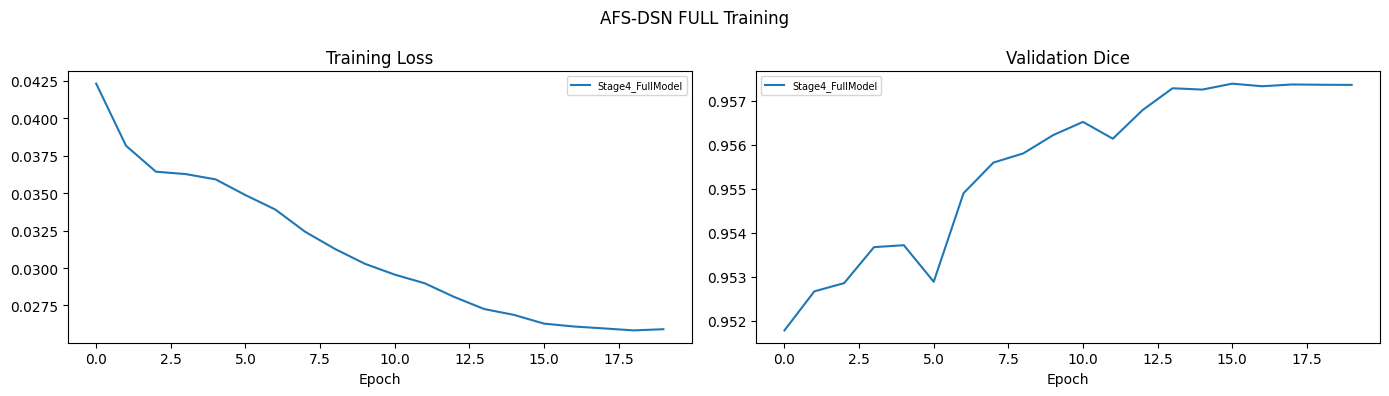

Saved: ./checkpoints_full/training_curves.png


In [11]:
# ============================================================
# Cell 6: Training curves
# ============================================================
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(14,4))
colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728']
for i,(name,h) in enumerate(history.items()):
    axes[0].plot(h['train_loss'],label=name,color=colors[i])
    axes[1].plot(h['val_dice'],  label=name,color=colors[i])
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Validation Dice'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.suptitle(f'AFS-DSN {VARIANT.upper()} Training',fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png',dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/training_curves.png')

In [12]:
import json
with open('./checkpoints_full/split_indices.json') as f:
    s = json.load(f)
print(f"Train:{len(s['train'])} Val:{len(s['val'])} Test:{len(s['test'])}")

Train:91 Val:19 Test:20
